In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
apps = pd.read_csv("apps.csv")
reviews = pd.read_csv("user_reviews.csv")

print("Apps dataset:")
display(apps.head())

print("\nUser Reviews dataset:")
display(reviews.head())

Apps dataset:


,Unnamed: 0,App,Category,Rating,Reviews,Size,Installs,Type,Price,Content Rating,Genres,Last Updated,Current Ver,Android Ver
0,0,Photo Editor & Candy Camera & Grid & ScrapBook,ART_AND_DESIGN,4.1,159,19.0,"10,000+",Free,0,Everyone,Art & Design,"January 7, 2018",1.0.0,4.0.3 and up
1,1,Coloring book moana,ART_AND_DESIGN,3.9,967,14.0,"500,000+",Free,0,Everyone,Art & Design;Pretend Play,"January 15, 2018",2.0.0,4.0.3 and up
2,2,"U Launcher Lite – FREE Live Cool Themes, Hide ...",ART_AND_DESIGN,4.7,87510,8.7,"5,000,000+",Free,0,Everyone,Art & Design,"August 1, 2018",1.2.4,4.0.3 and up
3,3,Sketch - Draw & Paint,ART_AND_DESIGN,4.5,215644,25.0,"50,000,000+",Free,0,Teen,Art & Design,"June 8, 2018",Varies with device,4.2 and up
4,4,Pixel Draw - Number Art Coloring Book,ART_AND_DESIGN,4.3,967,2.8,"100,000+",Free,0,Everyone,Art & Design;Creativity,"June 20, 2018",1.1,4.4 and up



User Reviews dataset:


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462
2,10 Best Foods for You,NaN,NaN,NaN,NaN
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000


In [3]:
print("Apps Dataset Shape:", apps.shape)
print("Reviews Dataset Shape:", reviews.shape)

print("\nApps Dataset Information:")
apps.info()

print("\nReviews Dataset Information:")
reviews.info()

Apps Dataset Shape: (9659, 14)
Reviews Dataset Shape: (64295, 5)

Apps Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Unnamed: 0      9659 non-null   int64  
 1   App             9659 non-null   str    
 2   Category        9659 non-null   str    
 3   Rating          8196 non-null   float64
 4   Reviews         9659 non-null   int64  
 5   Size            8432 non-null   float64
 6   Installs        9659 non-null   str    
 7   Type            9659 non-null   str    
 8   Price           9659 non-null   str    
 9   Content Rating  9659 non-null   str    
 10  Genres          9659 non-null   str    
 11  Last Updated    9659 non-null   str    
 12  Current Ver     9651 non-null   str    
 13  Android Ver     9657 non-null   str    
dtypes: float64(2), int64(2), str(10)
memory usage: 1.9 MB

Reviews Dataset Information:
<cl

In [4]:
# Check missing values
print("Missing values in Apps dataset:")
print(apps.isnull().sum())

print("\nMissing values in User Reviews dataset:")
print(reviews.isnull().sum())

Missing values in Apps dataset:
Unnamed: 0           0
App                  0
Category             0
Rating            1463
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64

Missing values in User Reviews dataset:
App                           0
Translated_Review         26868
Sentiment                 26863
Sentiment_Polarity        26863
Sentiment_Subjectivity    26863
dtype: int64


In [5]:
# Check duplicate rows
print("Duplicate rows in Apps dataset:", apps.duplicated().sum())
print("Duplicate rows in Reviews dataset:", reviews.duplicated().sum())

# Remove duplicate rows
apps = apps.drop_duplicates()
reviews = reviews.drop_duplicates()

print("\nDuplicates removed successfully.")
print("Apps shape:", apps.shape)
print("Reviews shape:", reviews.shape)

Duplicate rows in Apps dataset: 0
Duplicate rows in Reviews dataset: 33616

Duplicates removed successfully.
Apps shape: (9659, 14)
Reviews shape: (30679, 5)


In [6]:
print("Apps columns:")
print(apps.columns.tolist())

print("\nReviews columns:")
print(reviews.columns.tolist())

Apps columns:
['Unnamed: 0', 'App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']

Reviews columns:
['App', 'Translated_Review', 'Sentiment', 'Sentiment_Polarity', 'Sentiment_Subjectivity']


In [7]:
apps = apps.drop(columns=['Unnamed: 0'])

print("Column removed successfully!")
print(apps.columns.tolist())

Column removed successfully!
['App', 'Category', 'Rating', 'Reviews', 'Size', 'Installs', 'Type', 'Price', 'Content Rating', 'Genres', 'Last Updated', 'Current Ver', 'Android Ver']


In [8]:
apps['Reviews'] = pd.to_numeric(apps['Reviews'], errors='coerce')

print(apps['Reviews'].dtype)

int64


In [9]:
apps['Installs'] = (
    apps['Installs']
    .astype(str)
    .str.replace(',', '', regex=False)
    .str.replace('+', '', regex=False)
)

apps['Installs'] = pd.to_numeric(apps['Installs'], errors='coerce')

print(apps['Installs'].head())

0       10000
1      500000
2     5000000
3    50000000
4      100000
Name: Installs, dtype: int64


In [10]:
apps['Price'] = (
    apps['Price']
    .astype(str)
    .str.replace('$', '', regex=False)
)

apps['Price'] = pd.to_numeric(apps['Price'], errors='coerce')

print(apps['Price'].head())

0    0.0
1    0.0
2    0.0
3    0.0
4    0.0
Name: Price, dtype: float64


In [11]:
apps.info()

<class 'pandas.DataFrame'>
RangeIndex: 9659 entries, 0 to 9658
Data columns (total 13 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   App             9659 non-null   str    
 1   Category        9659 non-null   str    
 2   Rating          8196 non-null   float64
 3   Reviews         9659 non-null   int64  
 4   Size            8432 non-null   float64
 5   Installs        9659 non-null   int64  
 6   Type            9659 non-null   str    
 7   Price           9659 non-null   float64
 8   Content Rating  9659 non-null   str    
 9   Genres          9659 non-null   str    
 10  Last Updated    9659 non-null   str    
 11  Current Ver     9651 non-null   str    
 12  Android Ver     9657 non-null   str    
dtypes: float64(3), int64(2), str(8)
memory usage: 1.7 MB


In [12]:
# Check missing values in important columns
print("Missing values before cleaning:")
print(apps[['Rating', 'Category', 'Type', 'Price', 'Content Rating']].isnull().sum())

Missing values before cleaning:
Rating            1463
Category             0
Type                 0
Price                0
Content Rating       0
dtype: int64


In [13]:
# Fill missing ratings with the median rating
apps['Rating'] = apps['Rating'].fillna(apps['Rating'].median())

print("Missing ratings after cleaning:", apps['Rating'].isnull().sum())

Missing ratings after cleaning: 0


In [14]:
# Remove rows where essential information is missing
apps = apps.dropna(subset=['Category', 'Type', 'Content Rating'])

print("Remaining rows:", apps.shape[0])

Remaining rows: 9659


In [15]:
print("Missing values after cleaning:")
print(apps.isnull().sum())

Missing values after cleaning:
App                  0
Category             0
Rating               0
Reviews              0
Size              1227
Installs             0
Type                 0
Price                0
Content Rating       0
Genres               0
Last Updated         0
Current Ver          8
Android Ver          2
dtype: int64


In [16]:
category_counts = apps['Category'].value_counts()

print(category_counts)

Category
FAMILY                 1832
GAME                    959
TOOLS                   827
BUSINESS                420
MEDICAL                 395
PERSONALIZATION         376
PRODUCTIVITY            374
LIFESTYLE               369
FINANCE                 345
SPORTS                  325
COMMUNICATION           315
HEALTH_AND_FITNESS      288
PHOTOGRAPHY             281
NEWS_AND_MAGAZINES      254
SOCIAL                  239
BOOKS_AND_REFERENCE     222
TRAVEL_AND_LOCAL        219
SHOPPING                202
DATING                  171
VIDEO_PLAYERS           163
MAPS_AND_NAVIGATION     131
EDUCATION               119
FOOD_AND_DRINK          112
ENTERTAINMENT           102
AUTO_AND_VEHICLES        85
LIBRARIES_AND_DEMO       84
WEATHER                  79
HOUSE_AND_HOME           74
ART_AND_DESIGN           64
EVENTS                   64
PARENTING                60
COMICS                   56
BEAUTY                   53
Name: count, dtype: int64


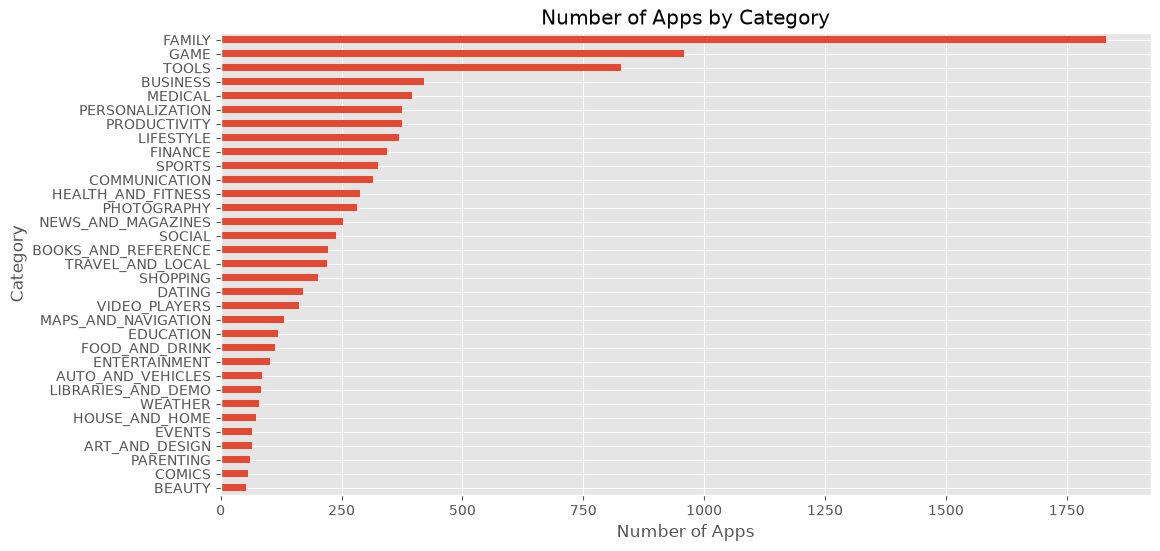

In [17]:
plt.figure(figsize=(12, 6))

category_counts.sort_values().plot(kind='barh')

plt.title('Number of Apps by Category')
plt.xlabel('Number of Apps')
plt.ylabel('Category')

plt.show()

In [18]:
top_categories = apps['Category'].value_counts().head(10)

print(top_categories)

Category
FAMILY             1832
GAME                959
TOOLS               827
BUSINESS            420
MEDICAL             395
PERSONALIZATION     376
PRODUCTIVITY        374
LIFESTYLE           369
FINANCE             345
SPORTS              325
Name: count, dtype: int64


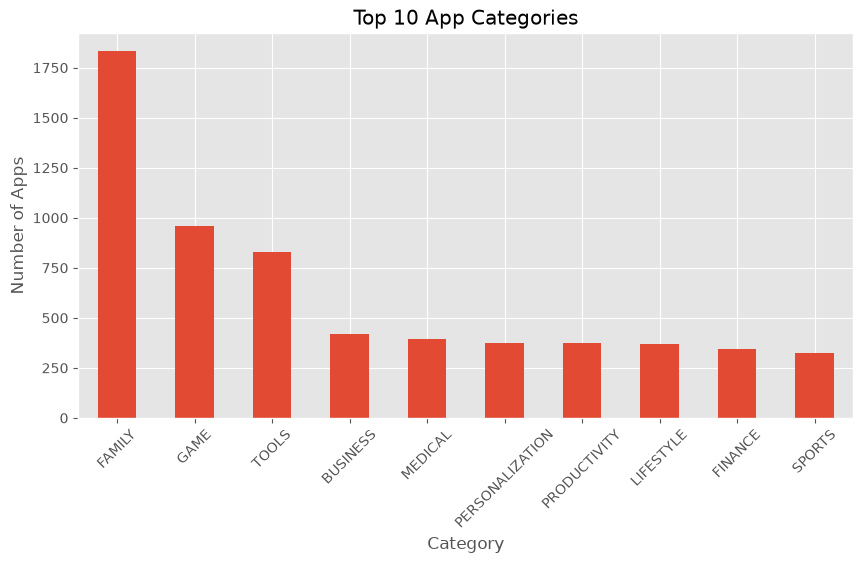

In [19]:
plt.figure(figsize=(10, 5))

top_categories.plot(kind='bar')

plt.title('Top 10 App Categories')
plt.xlabel('Category')
plt.ylabel('Number of Apps')
plt.xticks(rotation=45)

plt.show()

## Category Exploration

The category analysis shows how applications are distributed across different segments of the Google Play Store.

The most common categories represent areas with a large number of available applications, while categories with fewer applications may represent more specialized segments of the market.

In [21]:
print("Average Rating:", apps['Rating'].mean())
print("Highest Rating:", apps['Rating'].max())
print("Lowest Rating:", apps['Rating'].min())

Average Rating: 4.192442281809711
Highest Rating: 5.0
Lowest Rating: 1.0


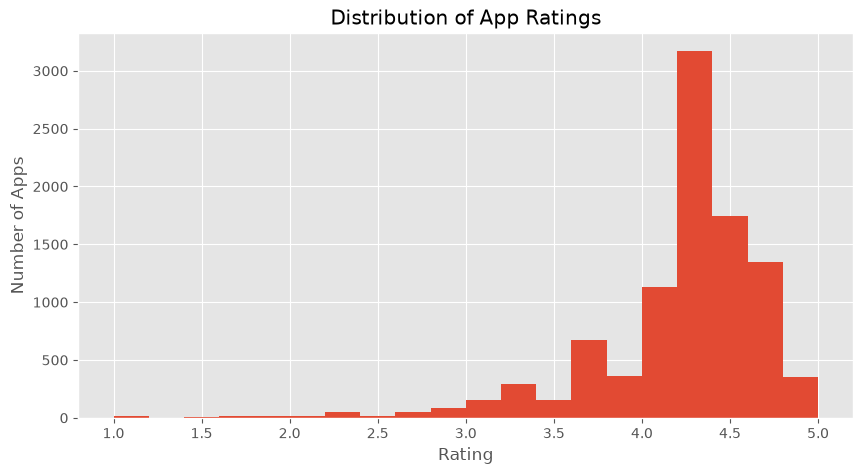

In [22]:
plt.figure(figsize=(10, 5))

plt.hist(apps['Rating'], bins=20)

plt.title('Distribution of App Ratings')
plt.xlabel('Rating')
plt.ylabel('Number of Apps')

plt.show()

In [23]:
category_rating = (
    apps.groupby('Category')['Rating']
    .mean()
    .sort_values(ascending=False)
)

print(category_rating)

Category
EVENTS                 4.395313
EDUCATION              4.363866
ART_AND_DESIGN         4.354687
BOOKS_AND_REFERENCE    4.334234
PERSONALIZATION        4.325532
PARENTING              4.300000
BEAUTY                 4.283019
SOCIAL                 4.255230
HEALTH_AND_FITNESS     4.251736
GAME                   4.249948
WEATHER                4.248101
SHOPPING               4.237624
SPORTS                 4.232923
LIBRARIES_AND_DEMO     4.207143
PRODUCTIVITY           4.206150
AUTO_AND_VEHICLES      4.205882
MEDICAL                4.202025
FAMILY                 4.194378
FOOD_AND_DRINK         4.192857
COMICS                 4.185714
HOUSE_AND_HOME         4.174324
BUSINESS               4.173810
PHOTOGRAPHY            4.166548
NEWS_AND_MAGAZINES     4.156693
COMMUNICATION          4.154921
FINANCE                4.138551
ENTERTAINMENT          4.135294
LIFESTYLE              4.131436
TRAVEL_AND_LOCAL       4.103196
TOOLS                  4.073881
VIDEO_PLAYERS          4.068098

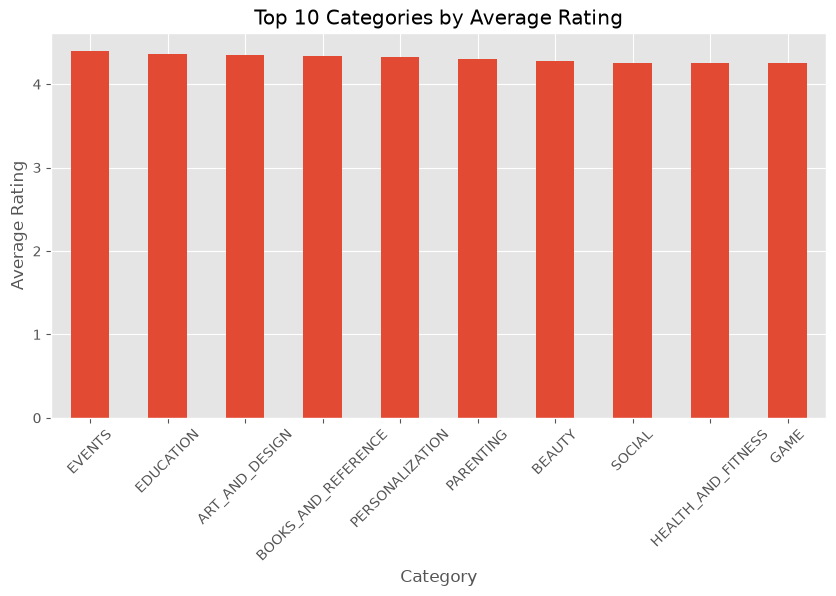

In [24]:
top_rated_categories = category_rating.head(10)

plt.figure(figsize=(10, 5))

top_rated_categories.plot(kind='bar')

plt.title('Top 10 Categories by Average Rating')
plt.xlabel('Category')
plt.ylabel('Average Rating')
plt.xticks(rotation=45)

plt.show()

## Ratings Analysis

The rating distribution shows how users have evaluated applications on the Google Play Store.

The average rating by category helps identify which app categories receive relatively higher user ratings. This provides an indication of user satisfaction across different segments of the app market.

In [26]:
top_reviewed_apps = apps[['App', 'Reviews']].sort_values(
    by='Reviews',
    ascending=False
).head(10)

top_reviewed_apps

,App,Reviews
2002,Facebook,78158306
300,WhatsApp Messenger,69119316
2003,Instagram,66577313
299,Messenger – Text and Video Chat for Free,56642847
1372,Clash of Clans,44891723
3181,Clean Master- Space Cleaner & Antivirus,42916526
1356,Subway Surfers,27722264
2908,YouTube,25655305
6486,"Security Master - Antivirus, VPN, AppLock, Boo...",24900999
1362,Clash Royale,23133508


In [27]:
top_installed_apps = apps[['App', 'Installs']].sort_values(
    by='Installs',
    ascending=False
).head(10)

top_installed_apps

,App,Installs
2977,Google News,1000000000
2012,Google+,1000000000
1356,Subway Surfers,1000000000
152,Google Play Books,1000000000
2908,YouTube,1000000000
2003,Instagram,1000000000
2930,Google Play Movies & TV,1000000000
2191,Google Photos,1000000000
2429,Google Street View,1000000000
701,Google Play Games,1000000000


<Figure size 1000x600 with 0 Axes>

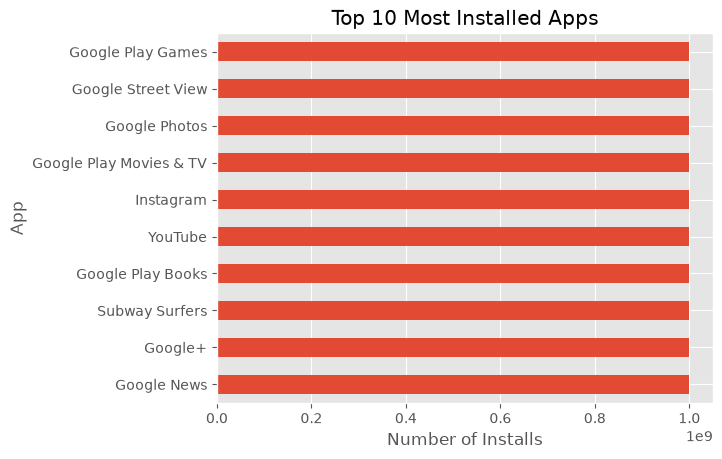

In [28]:
plt.figure(figsize=(10, 6))

top_installed_apps.sort_values('Installs').plot(
    x='App',
    y='Installs',
    kind='barh',
    legend=False
)

plt.title('Top 10 Most Installed Apps')
plt.xlabel('Number of Installs')
plt.ylabel('App')

plt.show()

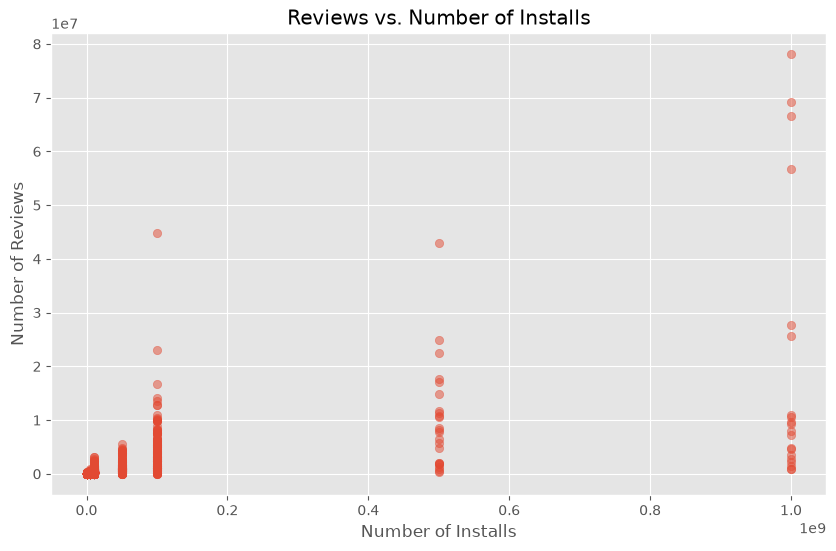

In [29]:
plt.figure(figsize=(10, 6))

plt.scatter(
    apps['Installs'],
    apps['Reviews'],
    alpha=0.5
)

plt.title('Reviews vs. Number of Installs')
plt.xlabel('Number of Installs')
plt.ylabel('Number of Reviews')

plt.show()

## App Popularity Analysis

The number of installs provides an indication of an application's popularity, while the number of reviews reflects user engagement.

Comparing installs and reviews helps identify whether highly downloaded applications also receive a large amount of user feedback.

In [30]:
type_counts = apps['Type'].value_counts()

print(type_counts)

Type
Free    8903
Paid     756
Name: count, dtype: int64


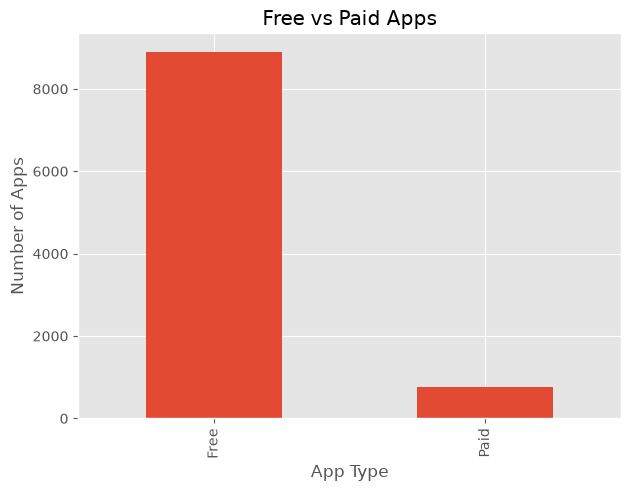

In [31]:
plt.figure(figsize=(7, 5))

type_counts.plot(kind='bar')

plt.title('Free vs Paid Apps')
plt.xlabel('App Type')
plt.ylabel('Number of Apps')

plt.show()

In [32]:
paid_apps = apps[apps['Type'] == 'Paid']

print("Number of paid apps:", len(paid_apps))
print("\nPrice statistics:")
print(paid_apps['Price'].describe())

Number of paid apps: 756

Price statistics:
count    756.000000
mean      14.045146
std       58.743615
min        0.990000
25%        1.490000
50%        2.990000
75%        4.990000
max      400.000000
Name: Price, dtype: float64


In [33]:
top_expensive = paid_apps[['App', 'Price']].sort_values(
    by='Price',
    ascending=False
).head(10)

top_expensive

,App,Price
3469,I'm Rich - Trump Edition,400.00
4400,I Am Rich Premium,399.99
4402,I am Rich!,399.99
4406,I Am Rich Pro,399.99
4398,I am Rich Plus,399.99
4417,I AM RICH PRO PLUS,399.99
8780,I'm Rich/Eu sou Rico/أنا غني/我很有錢,399.99
4413,I am Rich,399.99
4408,I am rich (Most expensive app),399.99
3327,most expensive app (H),399.99


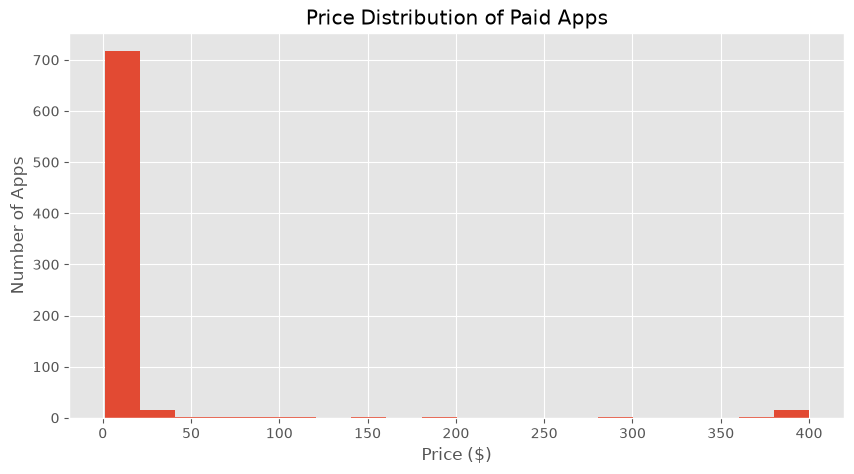

In [34]:
plt.figure(figsize=(10, 5))

plt.hist(paid_apps['Price'], bins=20)

plt.title('Price Distribution of Paid Apps')
plt.xlabel('Price ($)')
plt.ylabel('Number of Apps')

plt.show()

In [35]:
category_price = (
    paid_apps.groupby('Category')['Price']
    .mean()
    .sort_values(ascending=False)
)

print(category_price.head(10))

Category
FINANCE                170.637059
LIFESTYLE              124.256316
EVENTS                 109.990000
BUSINESS                14.607500
FAMILY                  13.113989
MEDICAL                 11.996386
PRODUCTIVITY             8.961786
PHOTOGRAPHY              6.225263
MAPS_AND_NAVIGATION      5.390000
SOCIAL                   5.323333
Name: Price, dtype: float64


## Pricing Analysis

The Google Play Store contains both free and paid applications.

The comparison of free and paid apps helps understand the dominant pricing model in the app market. The price analysis of paid applications shows how pricing varies across different categories.

These patterns can help developers understand the competitive pricing environment when planning a new application.

In [36]:
print("Total reviews:", len(reviews))

print("\nSentiment counts:")
print(reviews['Sentiment'].value_counts())

Total reviews: 30679

Sentiment counts:
Sentiment
Positive    19015
Negative     6321
Neutral      4361
Name: count, dtype: int64


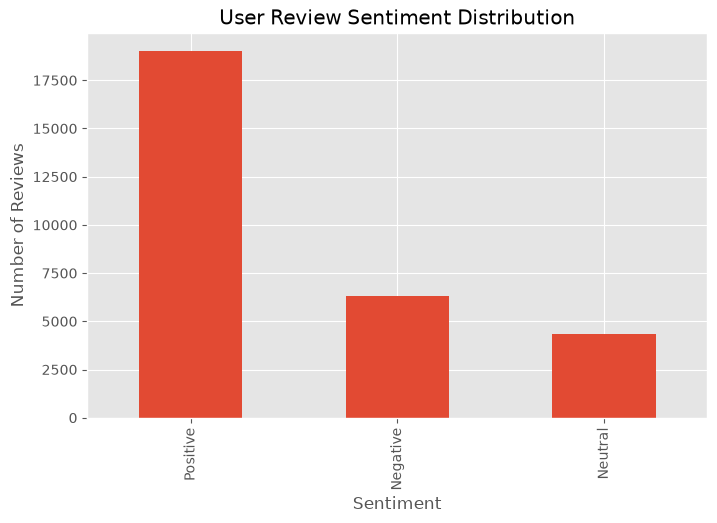

In [37]:
sentiment_counts = reviews['Sentiment'].value_counts()

plt.figure(figsize=(8, 5))

sentiment_counts.plot(kind='bar')

plt.title('User Review Sentiment Distribution')
plt.xlabel('Sentiment')
plt.ylabel('Number of Reviews')

plt.show()

In [38]:
sentiment_percentage = (
    reviews['Sentiment']
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print(sentiment_percentage)

Sentiment
Positive    64.03
Negative    21.28
Neutral     14.68
Name: proportion, dtype: float64


In [39]:
print("Average Sentiment Polarity:",
      reviews['Sentiment_Polarity'].mean())

print("\nPolarity Statistics:")
print(reviews['Sentiment_Polarity'].describe())

Average Sentiment Polarity: 0.18883621991609265

Polarity Statistics:
count    29697.000000
mean         0.188836
std          0.355672
min         -1.000000
25%          0.000000
50%          0.157143
75%          0.422500
max          1.000000
Name: Sentiment_Polarity, dtype: float64


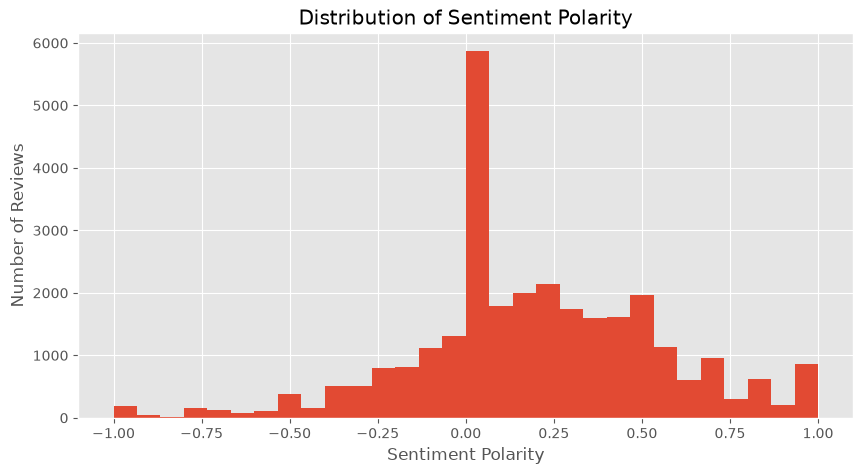

In [40]:
plt.figure(figsize=(10, 5))

plt.hist(
    reviews['Sentiment_Polarity'].dropna(),
    bins=30
)

plt.title('Distribution of Sentiment Polarity')
plt.xlabel('Sentiment Polarity')
plt.ylabel('Number of Reviews')

plt.show()

In [41]:
app_sentiment = pd.crosstab(
    reviews['App'],
    reviews['Sentiment']
)

app_sentiment['Total Reviews'] = app_sentiment.sum(axis=1)

top_reviewed_apps_sentiment = (
    app_sentiment
    .sort_values('Total Reviews', ascending=False)
    .head(10)
)

top_reviewed_apps_sentiment

Sentiment,Negative,Neutral,Positive,Total Reviews
App,,,,
Facebook,59,18,53,130
Episode - Choose Your Story,37,13,74,124
Angry Birds Classic,59,1,47,107
Family Locator - GPS Tracker,7,13,85,105
Google Photos,24,1,76,101
8fit Workouts & Meal Planner,11,7,82,100
Calorie Counter - MyFitnessPal,16,18,66,100
Calorie Counter - Macros,10,3,87,100
ColorNote Notepad Notes,6,2,91,99


## Sentiment Analysis

User reviews were analyzed to understand customer sentiment toward applications.

The dataset contains three sentiment categories: Positive, Negative, and Neutral. Sentiment distribution and polarity were analyzed to understand overall user feedback.

The sentiment analysis provides an additional perspective beyond app ratings by examining the nature of written user feedback.

In [42]:
# Keep only the columns needed for merging
app_category = apps[['App', 'Category']].drop_duplicates()

# Merge reviews with app categories
reviews_with_category = reviews.merge(
    app_category,
    on='App',
    how='left'
)

print("Merged dataset shape:", reviews_with_category.shape)

reviews_with_category.head()

Merged dataset shape: (30679, 6)


,App,Translated_Review,Sentiment,Sentiment_Polarity,Sentiment_Subjectivity,Category
0,10 Best Foods for You,I like eat delicious food. That's I'm cooking ...,Positive,1.00,0.533333,HEALTH_AND_FITNESS
1,10 Best Foods for You,This help eating healthy exercise regular basis,Positive,0.25,0.288462,HEALTH_AND_FITNESS
2,10 Best Foods for You,NaN,NaN,NaN,NaN,HEALTH_AND_FITNESS
3,10 Best Foods for You,Works great especially going grocery store,Positive,0.40,0.875000,HEALTH_AND_FITNESS
4,10 Best Foods for You,Best idea us,Positive,1.00,0.300000,HEALTH_AND_FITNESS


In [43]:
category_sentiment = pd.crosstab(
    reviews_with_category['Category'],
    reviews_with_category['Sentiment']
)

category_sentiment.head(10)

Sentiment,Negative,Neutral,Positive
Category,,,
ART_AND_DESIGN,54,60,240
AUTO_AND_VEHICLES,17,36,230
BEAUTY,60,81,176
BOOKS_AND_REFERENCE,84,106,427
BUSINESS,115,163,379
COMICS,1,6,39
COMMUNICATION,177,158,520
DATING,228,190,669
EDUCATION,75,81,488


In [44]:
top_positive_categories = (
    category_sentiment['Positive']
    .sort_values(ascending=False)
    .head(10)
)

print(top_positive_categories)

Category
GAME                  2567
HEALTH_AND_FITNESS    1262
FAMILY                1117
TOOLS                  842
FINANCE                841
TRAVEL_AND_LOCAL       831
MEDICAL                790
SPORTS                 770
PRODUCTIVITY           758
DATING                 669
Name: Positive, dtype: int64


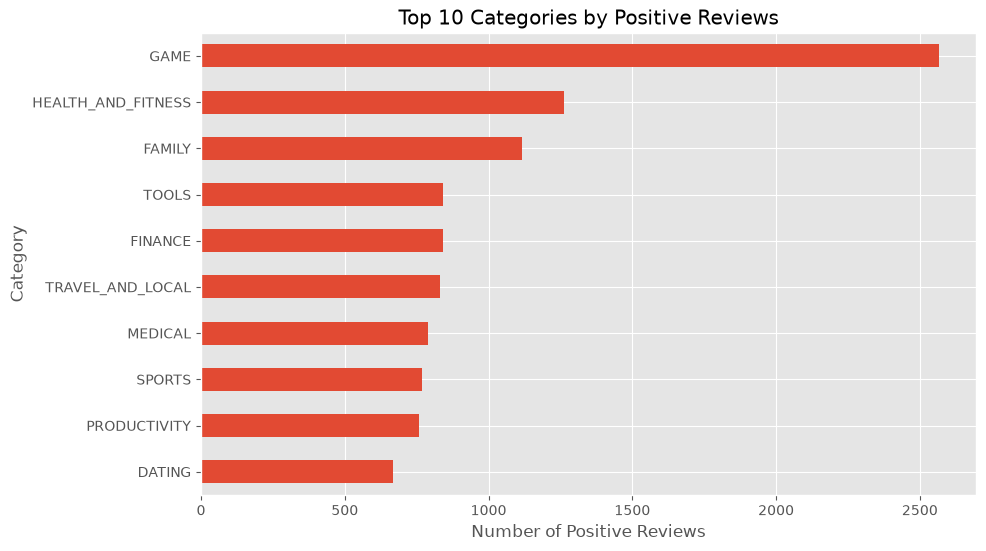

In [45]:
plt.figure(figsize=(10, 6))

top_positive_categories.sort_values().plot(kind='barh')

plt.title('Top 10 Categories by Positive Reviews')
plt.xlabel('Number of Positive Reviews')
plt.ylabel('Category')

plt.show()

In [46]:
top_negative_categories = (
    category_sentiment['Negative']
    .sort_values(ascending=False)
    .head(10)
)

print(top_negative_categories)

Category
GAME                1541
FAMILY               498
FINANCE              300
SPORTS               284
TRAVEL_AND_LOCAL     267
TOOLS                239
DATING               228
ENTERTAINMENT        213
PRODUCTIVITY         208
SOCIAL               190
Name: Negative, dtype: int64


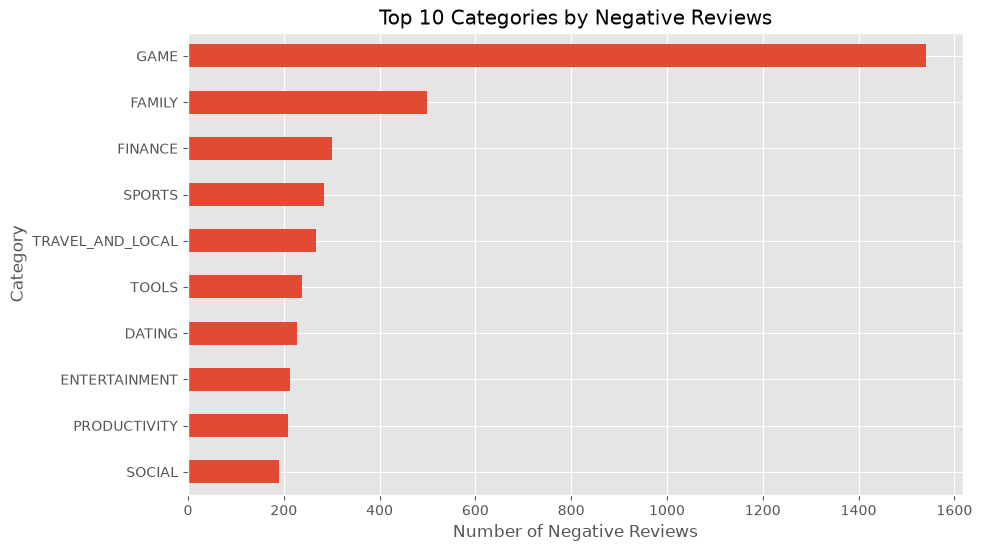

In [47]:
plt.figure(figsize=(10, 6))

top_negative_categories.sort_values().plot(kind='barh')

plt.title('Top 10 Categories by Negative Reviews')
plt.xlabel('Number of Negative Reviews')
plt.ylabel('Category')

plt.show()

## Sentiment by Category

User reviews were combined with app category information to understand sentiment across different sections of the Google Play Store.

The analysis identifies categories with relatively high numbers of positive and negative reviews. These results can help developers understand user satisfaction and areas where applications may need improvement.

In [48]:
import plotly.express as px

fig = px.bar(
    top_positive_categories.reset_index(),
    x='Positive',
    y='Category',
    orientation='h',
    title='Top 10 Categories by Positive Reviews'
)

fig.show()

In [49]:
summary = pd.DataFrame({
    'Metric': [
        'Total Apps',
        'Total Reviews',
        'Average Rating',
        'Free Apps',
        'Paid Apps',
        'Most Common Category'
    ],
    'Value': [
        len(apps),
        len(reviews),
        round(apps['Rating'].mean(), 2),
        (apps['Type'] == 'Free').sum(),
        (apps['Type'] == 'Paid').sum(),
        apps['Category'].value_counts().idxmax()
    ]
})

summary

,Metric,Value
0,Total Apps,9659
1,Total Reviews,30679
2,Average Rating,4.19
3,Free Apps,8903
4,Paid Apps,756
5,Most Common Category,FAMILY


## Key Insights

### 1. App Category Distribution
The category analysis shows that some categories contain significantly more applications than others. This indicates that certain areas of the Google Play Store are more competitive and saturated.

### 2. Free vs Paid Applications
Free applications make up the majority of the Google Play Store dataset, while paid applications represent a smaller portion. This suggests that the free-app model is more common in the analyzed dataset.

### 3. User Sentiment
The sentiment analysis shows the distribution of Positive, Negative, and Neutral user reviews. Positive reviews provide an indication of user satisfaction, while negative reviews can highlight areas where developers may need to improve their applications.

### 4. Ratings and Popularity
App ratings, reviews, and install counts provide different measures of app performance. A high number of installs indicates popularity, while ratings and reviews provide information about user satisfaction and engagement.

## Conclusion

This project analyzed the Google Play Store ecosystem using data cleaning, exploratory data analysis, visualization, and sentiment analysis.

The analysis explored app categories, ratings, installs, reviews, pricing, and user sentiment. Data preprocessing was performed to correct data types, handle missing values, remove duplicates, and prepare the dataset for analysis.

The results provide useful insights into app market distribution, user engagement, pricing patterns, and customer sentiment.

For a developer planning to launch a new application, understanding category competition, user preferences, pricing patterns, and review sentiment can help in making better data-driven decisions.

## Project Summary

**Dataset:** Google Play Store Apps and User Reviews

**Main Areas Analyzed:**
- App Categories
- Ratings
- Installs
- Reviews
- Free vs Paid Apps
- Pricing
- User Sentiment
- Sentiment by Category

**Tools Used:**
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Plotly
- Jupyter Notebook